# ***Decision Trees*** 

## ***Training & visualizing Decision Tree***

In [50]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import numpy as np
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)

x_iris = iris.data[['petal length (cm)', 'petal width (cm)']].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(x_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [51]:
# Visualize the decision tree
from sklearn.tree import export_graphviz
export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=['petal length (cm)', 'petal width (cm)'],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

In [52]:
!pip install graphviz

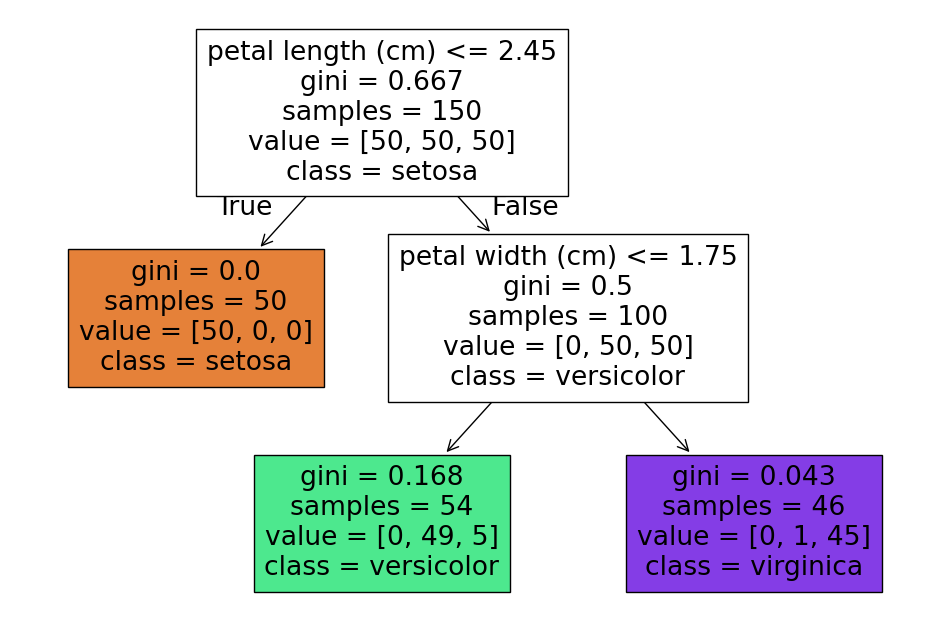

In [53]:
from graphviz import Source
Source.from_file("iris_tree.dot")

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plot_tree(tree_clf, feature_names=['petal length (cm)', 'petal width (cm)'], class_names=iris.target_names, filled=True)
plt.show()

## ***Making prediction*** 

<!-- 
A node’s samples attribute counts how many training instances it applies to. For example, 100 training instances have a petal length greater than 2.45 cm (depth 1, right), and of those 100, 54 have a petal width smaller than 1.75 cm (depth 2, left). A node’s value attribute tells you how many training instances of each class this node applies to: for example, the bottom-right node applies to 0 Iris setosa, 1 Iris versicolor, and 45 Iris virginica. Finally, a node’s gini attribute measures its Gini impurity: a node is “pure” (gini=0) if all training instances it applies to belong to the same class. For example, since the depth-1 left node applies only to Iris setosa training instances, its Gini impurity is 0. Conversely, the other nodes all apply to instances of multiple classes, so they are “impure”. Equation 5-1 shows how the training algorithm computes the Gini impurity Gi of the ith node. The more classes and the more mixed they are, the larger the impurity. For example, the depth-2 left node has a Gini impurity equal to 1 – (0/54)2 – (49/54)2 – (5/54)2 ≈ 0.168.
-->

- A node is pure if all the training instances belong to the same class
- The more classes & the more mixed up the node are larger the impure are

***Gini Impurity***
$$G = 1 - \sum_{k=1}^{n}p_{i,k}^2$$
- $G_i$ is the gini impurity of the $i^{th}$ node

- $p_{i, k}$ is the ratio of k instances among the training instances in $i^{th}$ node

Node is the point where the tree contain some subset of the training data

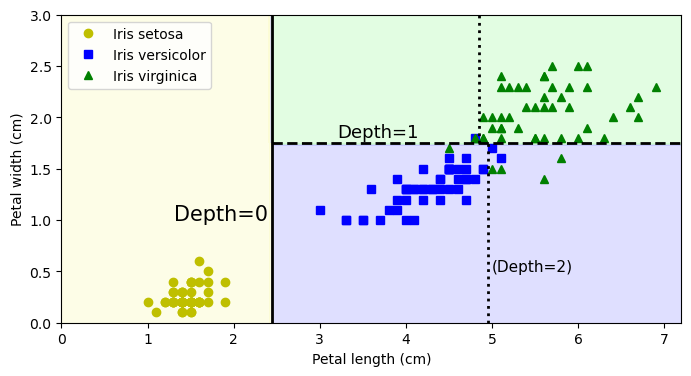

In [54]:
import numpy as np

from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
plt.figure(figsize=(8, 4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(x_iris[:, 0][y_iris == idx], x_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(x_iris, y_iris)
th0, th1, th2a, th2b = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.plot([th0, th0], [0, 3], "k-", linewidth=2)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2)
plt.plot([th2a, th2a], [0, th1], "k:", linewidth=2)
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth=2)
plt.text(th0 - 0.05, 1.0, "Depth=0", horizontalalignment="right", fontsize=15)
plt.text(3.2, th1 + 0.02, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.text(th2a + 0.05, 0.5, "(Depth=2)", fontsize=11)
plt.axis([0, 7.2, 0, 3])
plt.legend()

plt.show()

*Above diagram shows the decision boundories. The thick vertical line is DB for the root node(depth 0), left is pure so won't split anymore but the right is impure so that will split, as the `max_depth` is set to 2 the split will stop after another split*

<!-- MODEL INTERPRETATION: WHITE BOX VERSUS BLACK BOX 
Decision trees are intuitive, and their decisions are easy to interpret. Such models are often called white box models. In contrast, as you will see, random forests and neural networks are generally considered black box models. They make great predictions, and you can easily check the calculations that they performed to make these predictions; nevertheless, it is usually hard to explain in simple terms why the predictions were made. For example, if a neural network says that a particular person appears in a picture, it is hard to know what contributed to this prediction: Did the model recognize that person’s eyes? Their mouth? Their nose? Their shoes? Or even the couch that they were sitting on? Conversely, decision trees provide nice, simple classification rules that can even be applied manually if need be (e.g., for flower classification). The field of interpretable ML aims at creating ML systems that can explain their decisions in a way humans can understand. This is important in many domains, for example in healthcare, to let a doctor review the diagnosis; in finance, to let analysts understand the risks; in a judicial system, to let a human make the final call; or in human resources, to ensure decisions aren’t biased.  --> ...

## ***Estimating Class Probabilities***

***Decision tree can estimate the probability that an particular instance belongs to a particular class K***

In [55]:
tree_clf.predict_proba([[5, 1.5]]).round(3)
tree_clf.predict([[5, 1.5]])

array([1])

## ***CART training algo***

***SKlearn use Classification and Regression Tree algorithm to train decision tree***
- Split the training set into 2 subsets with a single feature `K` & threshold $t_K$ `(eg:prtial_length < 2.5)`
- It searches the for pair of K & $t_k$ that create the purest subset, weighted by their size 
$$J(k, t_k) = \frac{m_{left}}{m}G_{left} + \frac{m_{right}}{m}G_{right}$$

***Where~***
- $G_{left/right}$ measure the impurity of the left & right subset
- $m_{left/right}$ measures the instances in left & right subset
- $m = m_{left} + m_{right}$

- Once the CART algo splits the training set into 2, it splits the subsets using same logic, then the sub-subset
- It does this until it reaches the max_depth or the it can't find a split that reduce the impurity 

## ***Computational Complexity***

*Making prediction need to traverse the tree from root node to the leaf node*
- *Traversing the decision tree require going through $O(log_2(m))$ nodes, where $m$ is no of training instances*
- *Overall prediction complexity is $O(log_2(m))$*
- *By default the algo compare all features on all sample at each node, which cause training complexity $O(n \times m log_2(m))$*

## ***Gini impurity or Entropy?*** 
$$H_i = - \sum_{k=1, p_{i,k} \neq 0}^{n} p_i, k log_2(p_i, k)$$
- *Both create the same tree GI is just a bit faster than entropy*

## ***Regularization Hyperparameters***

*Decision tree make very few assumption about training data*
- *Decision tree is `nonparametric model` ass the number of parameters are not determined prior to training so the model stick close to the data which cause overfitting*
- *So to avoid overfitting we restrict the freedom of the tree during training & this is called `regularization`*
- *Very first hyperparameter is `max_depth` , few more which restrict the shape of the deccision tree are ~ `max_feature`, `max_leaf_nodes`, `min_sample_splits`, `min_sample_leaf`, `min_weight_fraction_leaf`, `min_impurity_decreases`, `ccp_alpha`*

In [56]:
# Regularization on moons dataset

from sklearn.datasets import make_moons

x_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

tree_clf1.fit(x_moons, y_moons)
tree_clf2.fit(x_moons, y_moons)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

In [57]:
x_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.4, random_state=43)

tree_clf1.score(x_moons_test, y_moons_test)

0.841

In [58]:
tree_clf2.score(x_moons_test, y_moons_test)

0.838

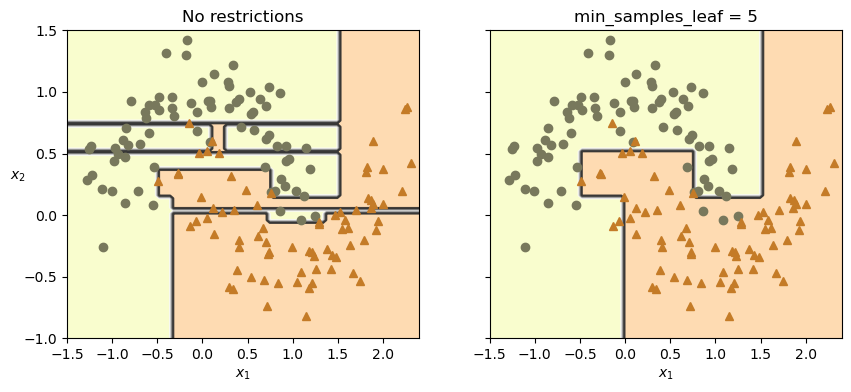

In [59]:
# plot diagram of decision boundaries
def plot_decision_boundary(clf, X, y, axes, cmap):
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap)
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8)
    colors = {"Wistia": ["#78785c", "#c47b27"], "Pastel1": ["red", "blue"]}
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[cmap][idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf1, x_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title("No restrictions")
plt.sca(axes[1])
plot_decision_boundary(tree_clf2, x_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}")
plt.ylabel("")

plt.show()

## ***Regression***

- *DT are also capable of performing regression tasks* 
- *When the linear regression work well in Linear data DT works well with every type of data*


In [60]:
from sklearn.tree import DecisionTreeRegressor
rng = np.random.default_rng(seed=42)

x_quad = rng.random((200, 1)) - 0.5 # single random input  
y_quad = x_quad **2 + 0.025 * rng.standard_normal((200, 1))

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(x_quad, y_quad)

DecisionTreeRegressor(max_depth=2, random_state=42)

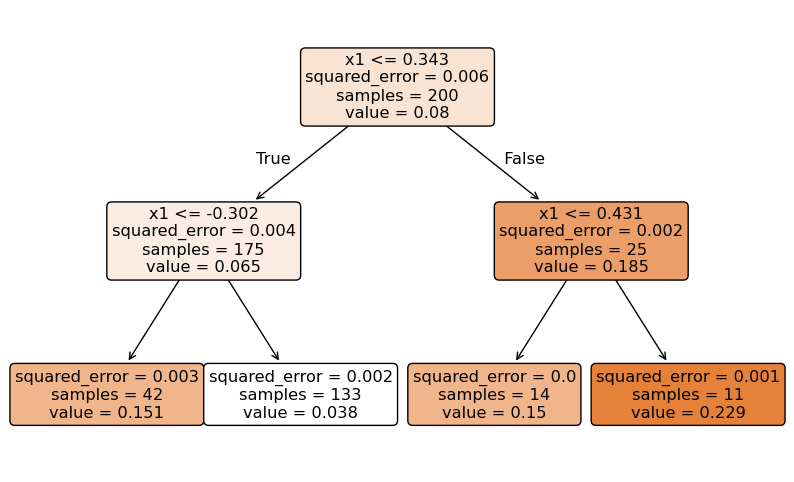

In [61]:
# from sklearn.tree import export_graphviz
# from graphviz import Source
# export_graphviz(
#     tree_reg,
#     out_file="my_regression_tree.dot",
#     feature_names=["x1"],
#     rounded=True,
#     filled=True
# )
# Source.from_file("my_regression_tree.dot")

plt.figure(figsize=(10, 6))

plot_tree(
    tree_reg,
    feature_names=["x1"],
    filled=True,
    rounded=True
)

plt.show()

***The tree look very much like the classification tree, but instead of predicting class in each node this predict value***

In [62]:
tree_reg2 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg2.fit(x_quad, y_quad)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [63]:
tree_reg.tree_.threshold

array([ 0.34304063, -0.30182856, -2.        , -2.        ,  0.43140428,
       -2.        , -2.        ])

In [64]:
tree_reg2.tree_.threshold

array([ 0.34304063, -0.30182856, -0.41395289, -2.        , -2.        ,
        0.21817657, -2.        , -2.        ,  0.43140428,  0.39480372,
       -2.        , -2.        ,  0.46470371, -2.        , -2.        ])

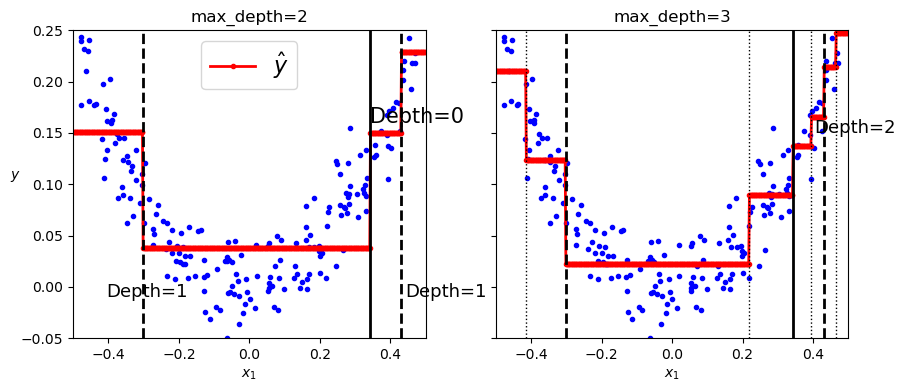

In [65]:
def plot_regression_predictions(tree_reg, X, y, axes=[-0.5, 0.5, -0.05, 0.25]):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$")
    plt.plot(X, y, "b.")
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_regression_predictions(tree_reg, x_quad, y_quad)

th0, th1a, th1b = tree_reg.tree_.threshold[[0, 1, 4]]
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)
plt.text(th0, 0.16, "Depth=0", fontsize=15)
plt.text(th1a + 0.01, -0.01, "Depth=1", horizontalalignment="center", fontsize=13)
plt.text(th1b + 0.01, -0.01, "Depth=1", fontsize=13)
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center", fontsize=16)
plt.title("max_depth=2")

plt.sca(axes[1])
th2s = tree_reg2.tree_.threshold[[2, 5, 9, 12]]
plot_regression_predictions(tree_reg2, x_quad, y_quad)
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)
for split in th2s:
    plt.plot([split, split], [-0.05, 0.25], "k:", linewidth=1)
plt.text(th2s[2] + 0.01, 0.15, "Depth=2", fontsize=13)
plt.title("max_depth=3")

plt.show()

*CART algo works the same way instead of trying split based on minimizing the impurity, it split to minimize MSE*

***CAST cost function for regression~***
$$J(k, t_k) = \frac{m_{left}}{m} MSE_{left} + \frac{m_{right}}{m} MSE_{right}$$

***Where~***
$$MSE_{node} = \frac{\sum_{i \in node}(\hat y_{node} - y^{(i)})^2}{m_{node}}$$
$$\hat y_{node} = \frac{\sum_{i \in node} y^{(i)}}{m_{node}}$$

***Just like classification task decision tree is prone to overfitting without any regularization while dealing with regression task***

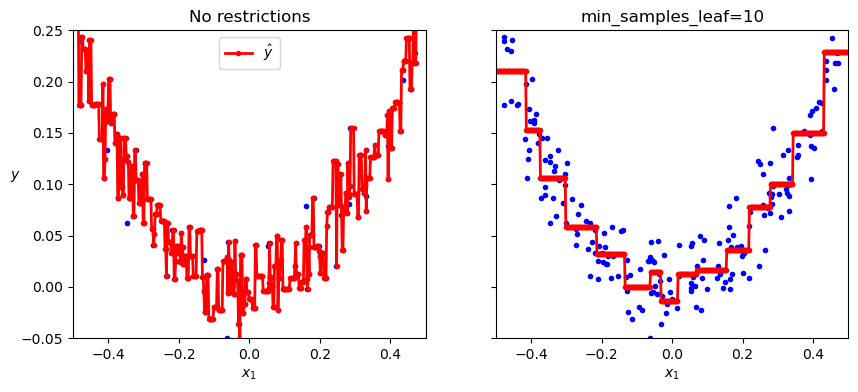

In [66]:
tree_reg1 = DecisionTreeRegressor(random_state=42)
tree_reg2 = DecisionTreeRegressor(random_state=42, min_samples_leaf=10)
tree_reg1.fit(x_quad, y_quad)
tree_reg2.fit(x_quad, y_quad)

x1 = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)
y_pred1 = tree_reg1.predict(x1)
y_pred2 = tree_reg2.predict(x1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plt.plot(x_quad, y_quad, "b.")
plt.plot(x1, y_pred1, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center")
plt.title("No restrictions")

plt.sca(axes[1])
plt.plot(x_quad, y_quad, "b.")
plt.plot(x1, y_pred2, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.title(f"min_samples_leaf={tree_reg2.min_samples_leaf}")

plt.show()

## ***Sensitivity to axis orientation***

*DT have some limitation*
*All the splits in DT are perpendicular to the axis which make them sensitive to the orientation of the data*
- *Like say the data splits nicely & if we rotate the orientation by 45 degree the boundary will look convoluted, so that won't generalize well*

***One way to get rid of this is to scale the data & then perform PCA transformation*** 


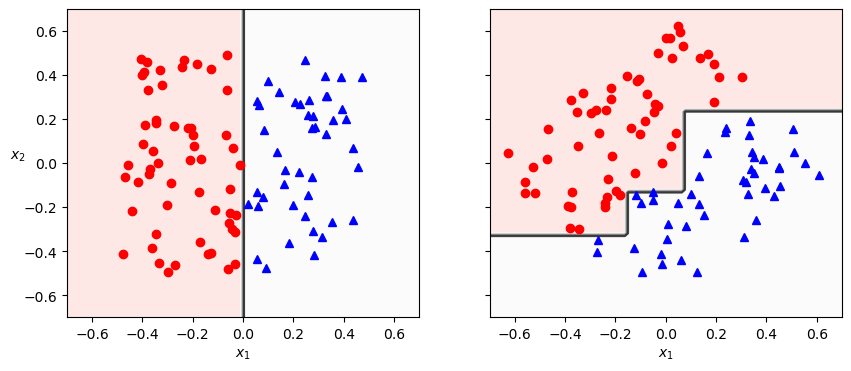

In [67]:
rng = np.random.default_rng(seed=42)
X_square = rng.random((100, 2)) - 0.5
y_square = (X_square[:, 0] > 0).astype(np.int64)

angle = np.pi / 4  # 45 degrees
rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)],
                            [np.sin(angle), np.cos(angle)]])
X_rotated_square = X_square.dot(rotation_matrix)

tree_clf_square = DecisionTreeClassifier(random_state=42)
tree_clf_square.fit(X_square, y_square)
tree_clf_rotated_square = DecisionTreeClassifier(random_state=42)
tree_clf_rotated_square.fit(X_rotated_square, y_square)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf_square, X_square, y_square,
                       axes=[-0.7, 0.7, -0.7, 0.7], cmap="Pastel1")
plt.sca(axes[1])
plot_decision_boundary(tree_clf_rotated_square, X_rotated_square, y_square,
                       axes=[-0.7, 0.7, -0.7, 0.7], cmap="Pastel1")
plt.ylabel("")

plt.show()

In [68]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pca_pipeline = make_pipeline(StandardScaler(), PCA())
x_iris_rotated = pca_pipeline.fit_transform(x_iris)

tree_clf_pca = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf_pca.fit(x_iris_rotated, y_iris)


DecisionTreeClassifier(max_depth=2, random_state=42)

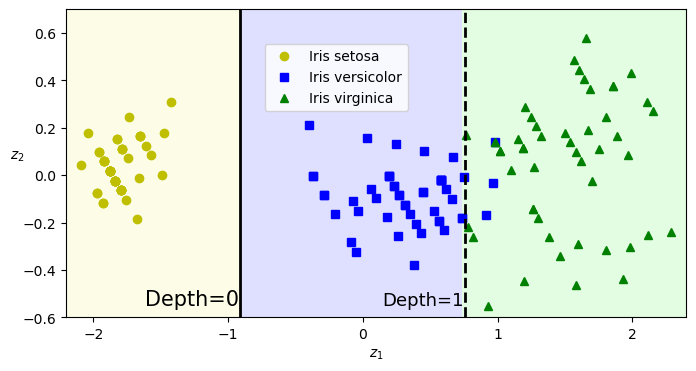

In [69]:
plt.figure(figsize=(8, 4))

axes = [-2.2, 2.4, -0.6, 0.7]
z0s, z1s = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                       np.linspace(axes[2], axes[3], 100))
X_iris_pca_all = np.c_[z0s.ravel(), z1s.ravel()]
y_pred = tree_clf_pca.predict(X_iris_pca_all).reshape(z0s.shape)

plt.contourf(z0s, z1s, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(x_iris_rotated[:, 0][y_iris == idx],
             x_iris_rotated[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

plt.xlabel("$z_1$")
plt.ylabel("$z_2$", rotation=0)
th1, th2 = tree_clf_pca.tree_.threshold[[0, 2]]
plt.plot([th1, th1], axes[2:], "k-", linewidth=2)
plt.plot([th2, th2], axes[2:], "k--", linewidth=2)
plt.text(th1 - 0.01, axes[2] + 0.05, "Depth=0",
         horizontalalignment="right", fontsize=15)
plt.text(th2 - 0.01, axes[2] + 0.05, "Depth=1",
         horizontalalignment="right", fontsize=13)
plt.axis(axes)
plt.legend(loc=(0.32, 0.67))

plt.show()

## ***Decision tree have hign Variance***

*DT has very high variance, even a small change in hyperparameter or the data may produce a different model* 
- *Also as the training algo is `stochastic` it randomly select the feature to evaluate to evaluate at each node, so that will procuce same model even after training the same DT with same data ~ unless set the random_state hyperparameter*

***By averaging prediction around many tree, it's possible to reduce the `variance` significantly, such ensemble tree is called `Random forest`***

In [70]:
tree_clf_tweaked = DecisionTreeClassifier(max_depth=2, random_state=40)
tree_clf_tweaked.fit(x_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=40)

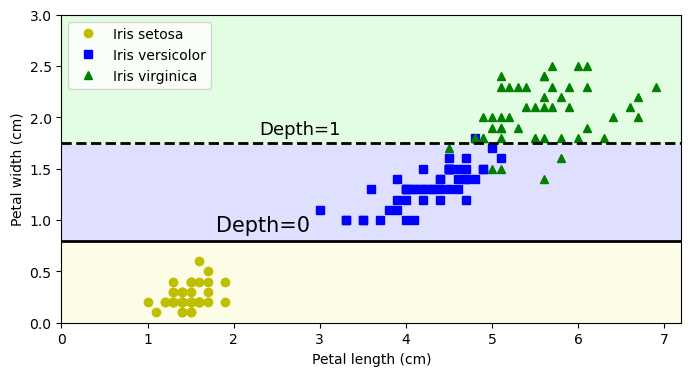

In [71]:
plt.figure(figsize=(8, 4))
y_pred = tree_clf_tweaked.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)

for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(x_iris[:, 0][y_iris == idx], x_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

th0, th1 = tree_clf_tweaked.tree_.threshold[[0, 2]]
plt.plot([0, 7.2], [th0, th0], "k-", linewidth=2)
plt.plot([0, 7.2], [th1, th1], "k--", linewidth=2)
plt.text(1.8, th0 + 0.05, "Depth=0", verticalalignment="bottom", fontsize=15)
plt.text(2.3, th1 + 0.05, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.axis([0, 7.2, 0, 3])
plt.legend()

plt.show()